In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, roc_auc_score#,plot_roc_curve
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


cosmos = pd.read_csv("neo.csv")
cosmos

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


In [2]:
cosmos = cosmos.drop(['id','name','orbiting_body','sentry_object'], axis=1) #porzucenie kolumn
cosmos

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,False
90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,False
90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,False
90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,False


In [41]:
# class count
#class_count_0, class_count_1 = cosmos['hazardous'].value_counts()

In [42]:
#class_0 = cosmos[cosmos['hazardous'] == 0]
#class_1 = cosmos[cosmos['hazardous'] == 1]
#print('class 0:', class_0.shape)
#print('class 1:', class_1.shape)

In [43]:
#class_0_under = class_0.sample(class_count_1) # balansowanie zbioru

#test_under = pd.concat([class_0_under, class_1], axis=0)

#print("total class of 1 and0:",test_under['hazardous'].value_counts())# plot the count after under-sampeling
#test_under['hazardous'].value_counts().plot(kind='bar', title='count (target)')

In [3]:
X = cosmos.drop(['hazardous'], axis=1) #stworzenie grup x,y 
y = cosmos['hazardous']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [7]:
rf_classifier = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=4, bootstrap=True, random_state=1)
rf_classifier.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(max_depth=4, n_estimators=10, random_state=1)

In [8]:
pred_train = rf_classifier.predict(X_train_balanced) #model.predict zwraca przynależność do klasy


In [9]:
pred_test = rf_classifier.predict(X_test)

In [10]:
print("Accuracy on training set: {:.2f}".format(rf_classifier.score(X_train_balanced, y_train_balanced)))
print("Accuracy on test set: {:.2f}".format(rf_classifier.score(X_test, y_test)))

Accuracy on training set: 0.88
Accuracy on test set: 0.79


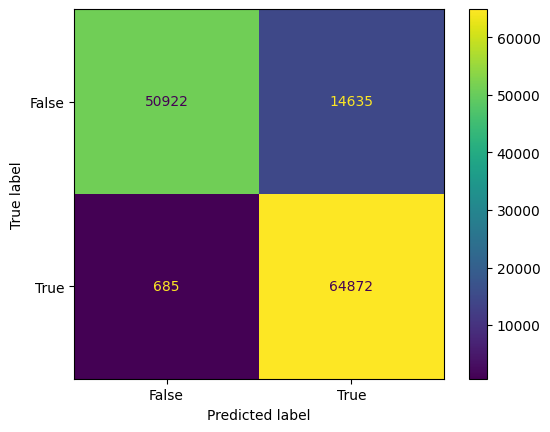

In [12]:
ConfusionMatrixDisplay.from_predictions(y_train_balanced,pred_train)

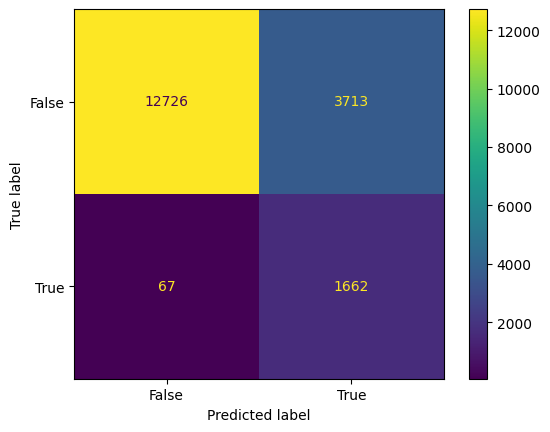

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test,pred_test)

In [19]:

print(classification_report(y_train_balanced, pred_train))

              precision    recall  f1-score   support

       False       0.99      0.78      0.87     65557
        True       0.82      0.99      0.89     65557

    accuracy                           0.88    131114
   macro avg       0.90      0.88      0.88    131114
weighted avg       0.90      0.88      0.88    131114



In [18]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

       False       0.99      0.77      0.87     16439
        True       0.31      0.96      0.47      1729

    accuracy                           0.79     18168
   macro avg       0.65      0.87      0.67     18168
weighted avg       0.93      0.79      0.83     18168

